# Prueba técnica - Consultor Analitico
*Laura Melisa Patarroyo Godoy*

**Problema de negocio:** Una compañía de telecomunicaciones peruana busca establecer accionables estratégicos y de negocio orientados a reducir las intenciones de cancelación de servicio y el abandono de clientes (churn). Para lo anterior, se realizó una segmentación de clientes y se identificó un clúster crítico (cluster 3) con alta propensión al churn y elevadas intenciones de cancelación.
**Objetivo**: diseñar iniciativas focalizadas para este Cluster clave (cluster3), con el fin de reducir el churn

Este análisis se centrará en entender los principales factores que impulsan el churn dentro de este clúster teniendo en cuenta las variables de segmentación de clientes y las transcripciones de llamadas de clientes

## **Roadmap Analítico**

El análisis seguirá el siguiente flujo:

*   Paso 1: Exploración de Datos. Aquí se revisaran las variables usadas para la segmentación y se identificarán patrones de comportamiento de los clientes del Clúster 3, para entender por que los hace ser tan 'críticos'.
*   Paso 2: Análisis de las transcripciones de las llamadas. Aquí se identificará las principales razones del churn, que los clientes expresan cuando realizan las llamadas con intenciones de cancelación, usando NLP.
*   Paso 3: Relacionar los hallazgos del Paso1 con los hallazgos del Paso2. Llamadas Vs Caracterización.
*   Paso 4: Diseño de Estrategias. Aquí se definirán las iniciativas de retención reactivas y proactivas, teniendo como base los resultados de los pasos anteriores.
*  Paso 5: Métricas de Impacto. Aquí se definirán KPIs para medir qué tan efectivas son las estrategias propuestas.

## **Exploración de Datos (EDA)**

In [16]:
!pip install wordcloud
!pip install gdown

In [133]:
# Importación principales librerias a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re

In [5]:
## Como el archivo que contiene el dataset del cluster es tan grande. Se leerá desde la URL de Drive.
import gdown
url = "https://drive.google.com/uc?id=1S8v5VLiF_t7rrhCwwUxKkQ3WkRgJZ49-"
gdown.download(url, "ANEXO_VARIABLES_CLUSTER_3.xlsx", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1S8v5VLiF_t7rrhCwwUxKkQ3WkRgJZ49-
From (redirected): https://drive.google.com/uc?id=1S8v5VLiF_t7rrhCwwUxKkQ3WkRgJZ49-&confirm=t&uuid=50d81f76-1158-4b69-aa8f-07929f3beb66
To: /content/ANEXO_VARIABLES_CLUSTER_3.xlsx
100%|██████████| 284M/284M [00:02<00:00, 103MB/s]


'ANEXO_VARIABLES_CLUSTER_3.xlsx'

In [8]:
## Lectura y creación de DF de los 2 archivos a analizar.
llamadas = pd.read_excel("https://raw.githubusercontent.com/lmelisapg/PruebaTecnica/main/datos/LLAMADAS_VF.xlsx")
cluster = pd.read_excel("ANEXO_VARIABLES_CLUSTER_3.xlsx")


In [18]:
## Se inicia con la exploración del DF del cluster3 de clientes.
## Tamaño del DF
cluster.shape


(555106, 129)

In [23]:
## Revisión de DF
cluster.head()

,CLUSTER_ID,PERIODO,ESTRATO,ANTIGUEDAD_MESES,BAN_TV,BAN_INTERNET,BAN_VOZ,VELOCIDAD_INTERNET_MBPS,VAL_SRV_BSC,CANT_SRV_BSC,...,MOTIVO_LLAM_NOV_TEC,MOTIVO_LLAM_SOPORTE_TEC,MOTIVO_LLAM_OTRO,CLASIF_OKK_IGUALCONDICION,CLASIF_OKK_MEJORCOMP,CLASIF_OKK_ALTACOMP,CLASIF_OKK_SOMOSUNICOS,CLASIF_OKK_SOMOSMEJORES,SEGMENTO_RE,SEGMENTO_PY
0,3,202508,3,16,1,1,1,900,3,4.0,...,0,0,0,0,0,1,0,0,1,0
1,3,202508,2,16,1,1,1,170,3,4.0,...,0,0,0,0,1,0,0,0,1,0
2,3,202508,1,16,1,1,1,450,3,4.0,...,0,0,0,0,0,1,0,0,1,0
3,3,202508,2,16,1,1,1,250,3,4.0,...,0,0,0,0,0,0,0,0,1,0
4,3,202508,2,100,1,1,1,350,3,4.0,...,0,0,0,0,0,1,0,0,1,0


In [28]:
## Verificación de que los datos sean solo del cluster3
cluster["CLUSTER_ID"].value_counts()

,count
CLUSTER_ID,
3,555106


In [77]:
pd.set_option('display.max_rows', None)

In [79]:
## Revisión de columnas del DF
cluster.columns

Index(['CLUSTER_ID', 'PERIODO', 'ESTRATO', 'ANTIGUEDAD_MESES', 'BAN_TV',
       'BAN_INTERNET', 'BAN_VOZ', 'VELOCIDAD_INTERNET_MBPS', 'VAL_SRV_BSC',
       'CANT_SRV_BSC',
       ...
       'MOTIVO_LLAM_SOPORTE_TEC', 'MOTIVO_LLAM_OTRO',
       'CLASIF_OKK_IGUALCONDICION', 'CLASIF_OKK_MEJORCOMP',
       'CLASIF_OKK_ALTACOMP', 'CLASIF_OKK_SOMOSUNICOS',
       'CLASIF_OKK_SOMOSMEJORES', 'SEGMENTO_RE', 'SEGMENTO_PY',
       'GRUPO_CANCELACION'],
      dtype='object', length=128)

Revisando el significado en el Diccionario de datos de las variables que tenemos, observamos que hay variables que nos dan información del cliente en cuanto al perfil, los servicios que tiene contratados, la facturación, interacciones con soporte, las caracteristicas del servicio que tiene, aplicación de campañas e intenciones de cancelación.

In [121]:
## Datos Faltantes
cluster.isnull().sum().sort_values(ascending=False).head(15)

,0
VAL_SCORE_CREDITICIO,6254
VAL_RENTA_BSC_IVA,3128
VAL_RENTA_ADIC_IVA,3128
VAL_DIAS_PAGO,527
VAL_DECO_BAS,29
CANT_SRV_ADIC,29
VAL_EQUIP_ADIC,29
CANT_SRV_BSC,29
VAL_MODEM_BAS,29
VAL_EQUIP_BAS,29


In [29]:
## Las variables VAL_PENETRACION_NODO y VAL_CHURN_ZONA están en su totalidad nulas, por lo que no aportan al entendimiento ni caracterización de los clientes.
cluster = cluster.drop(columns=["VAL_PENETRACION_NODO","VAL_CHURN_ZONA"])

Las otras variables que tienen algunos nulos se mantendrán ya que la proporción es mínima en comparación con el tamaño total del dataset. Y algunas siguiendo la descripción del diccionario de datos, pueden ser utiles al realizar el perfilamiento de los clientes.

In [34]:
pd.set_option('display.max_rows', None)

In [82]:
cluster.describe().T

,count,mean,std,min,25%,50%,75%,max
CLUSTER_ID,555106.0,3.000000e+00,0.000000e+00,3.000000e+00,3.00,3.000,3.000000e+00,3.000000e+00
PERIODO,555106.0,2.025080e+05,0.000000e+00,2.025080e+05,202508.00,202508.000,2.025080e+05,2.025080e+05
ANTIGUEDAD_MESES,555106.0,7.996819e+01,5.993527e+01,0.000000e+00,31.00,62.000,1.220000e+02,1.496000e+03
BAN_TV,555106.0,9.777376e-01,1.475359e-01,0.000000e+00,1.00,1.000,1.000000e+00,1.000000e+00
BAN_INTERNET,555106.0,9.972942e-01,5.194683e-02,0.000000e+00,1.00,1.000,1.000000e+00,1.000000e+00
BAN_VOZ,555106.0,9.700904e-01,1.703381e-01,0.000000e+00,1.00,1.000,1.000000e+00,1.000000e+00
VELOCIDAD_INTERNET_MBPS,555106.0,5.133877e+02,2.080604e+02,0.000000e+00,350.00,500.000,5.000000e+02,1.000000e+03
VAL_SRV_BSC,555106.0,2.945122e+00,2.719615e-01,0.000000e+00,3.00,3.000,3.000000e+00,3.000000e+00
CANT_SRV_BSC,555077.0,3.923185e+00,4.338358e-01,1.000000e+00,4.00,4.000,4.000000e+00,5.000000e+00
CANT_SRV_ADIC,555077.0,5.191622e+00,1.524280e+00,0.000000e+00,4.00,5.000,6.000000e+00,2.000000e+01


<Axes: xlabel='ANTIGUEDAD_MESES', ylabel='Count'>

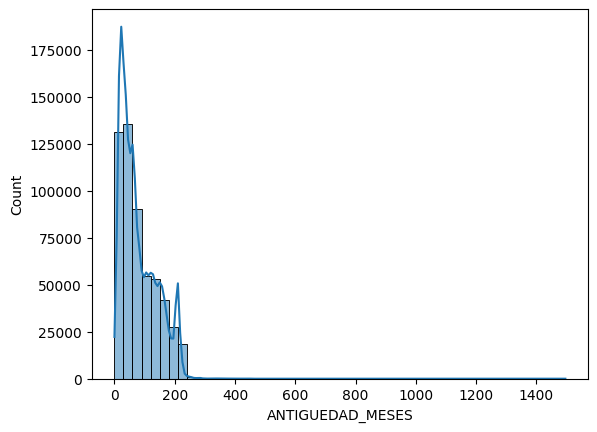

In [71]:
sns.histplot(cluster["ANTIGUEDAD_MESES"], bins=50, kde=True)

In [122]:
## Hay valores atipicos en la antiguedad, ya que más de 660 meses serian 50 años que una empresa lleve en el mercado
cluster[cluster["ANTIGUEDAD_MESES"] > 600].shape

(0, 128)

In [123]:
## La proporción es muy poca vs el total del dataset, por lo que unicamente vamos a realizar un Capping a estos valores:
cluster.loc[cluster["ANTIGUEDAD_MESES"] > 600, "ANTIGUEDAD_MESES"] = 360
cluster[cluster["ANTIGUEDAD_MESES"] > 600].shape

(0, 128)

In [86]:
## Hay valores atipicos en los minutos de interrupción al servicio. No deberian haber menores a 0. Reemplazamos por 0 para evitar distorsiones en el análisis.
cluster[cluster["VAL_DOWNTIME"] < 0].shape
cluster.loc[cluster["VAL_DOWNTIME"] < 0, "VAL_DOWNTIME"] = 0

In [87]:
cluster[cluster["VAL_DOWNTIME"] < 0].shape

(0, 128)

In [99]:
cluster["CANT_SRV_BSC"].value_counts()

## La mayoria de los clientes cuentan con al menos 4 servicios basicos contratados.

,count
CANT_SRV_BSC,
4.0,526843
2.0,10262
3.0,7861
1.0,6091
5.0,4020


In [96]:
cluster["CANT_SRV_ADIC"].value_counts().head(10)
## Los cllientes del cluster poseen entre 4 y 6 servicios adicionales

,count
CANT_SRV_ADIC,
5.0,163272
4.0,124267
6.0,117025
7.0,55409
3.0,46665
8.0,21577
2.0,11169
9.0,8502
10.0,3398


In [98]:
cluster[["ESTRATO_1","ESTRATO_2","ESTRATO_3","ESTRATO_4","ESTRATO_5","ESTRATO_6"]].mean()*100
# La mayoria de clientes del cluster están entre estratos 2-3: clase media.

,0
ESTRATO_1,6.386348
ESTRATO_2,41.862275
ESTRATO_3,37.344759
ESTRATO_4,12.386103
ESTRATO_5,0.324983
ESTRATO_6,1.666348


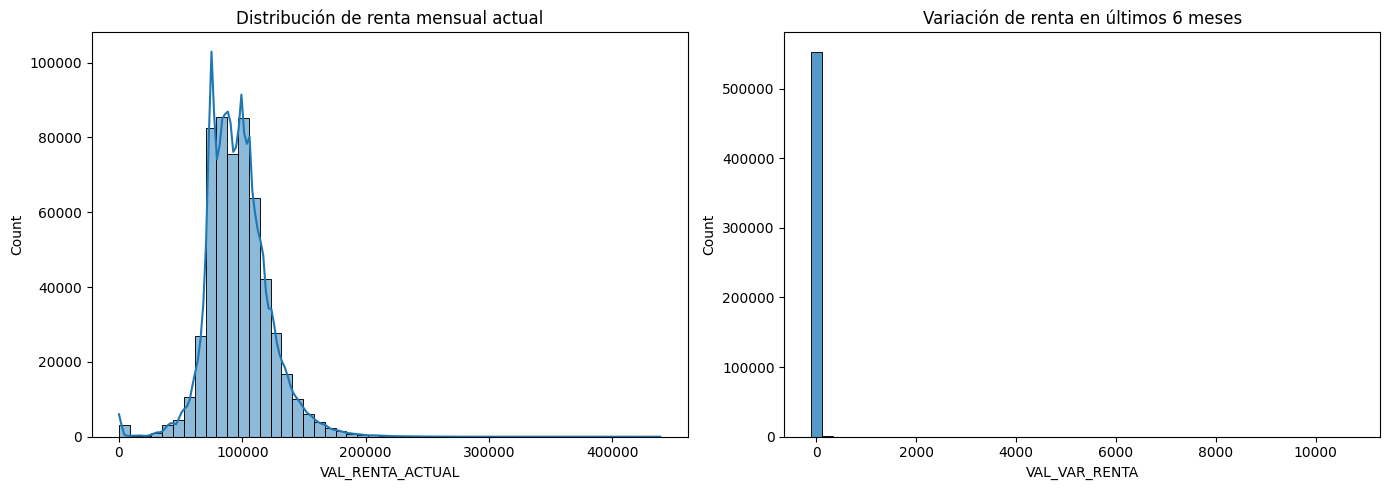

In [207]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(cluster["VAL_RENTA_ACTUAL"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución de renta mensual actual")

sns.histplot(cluster["VAL_VAR_RENTA"], bins=50, ax=axes[1])
axes[1].set_title("Variación de renta en últimos 6 meses")

plt.tight_layout()
plt.show()

La mayoria de clientes manejan una renta entre 80.000 – 110.000. Los precios se mantienen relativamente estables, no se observan muchos cambios en la factura

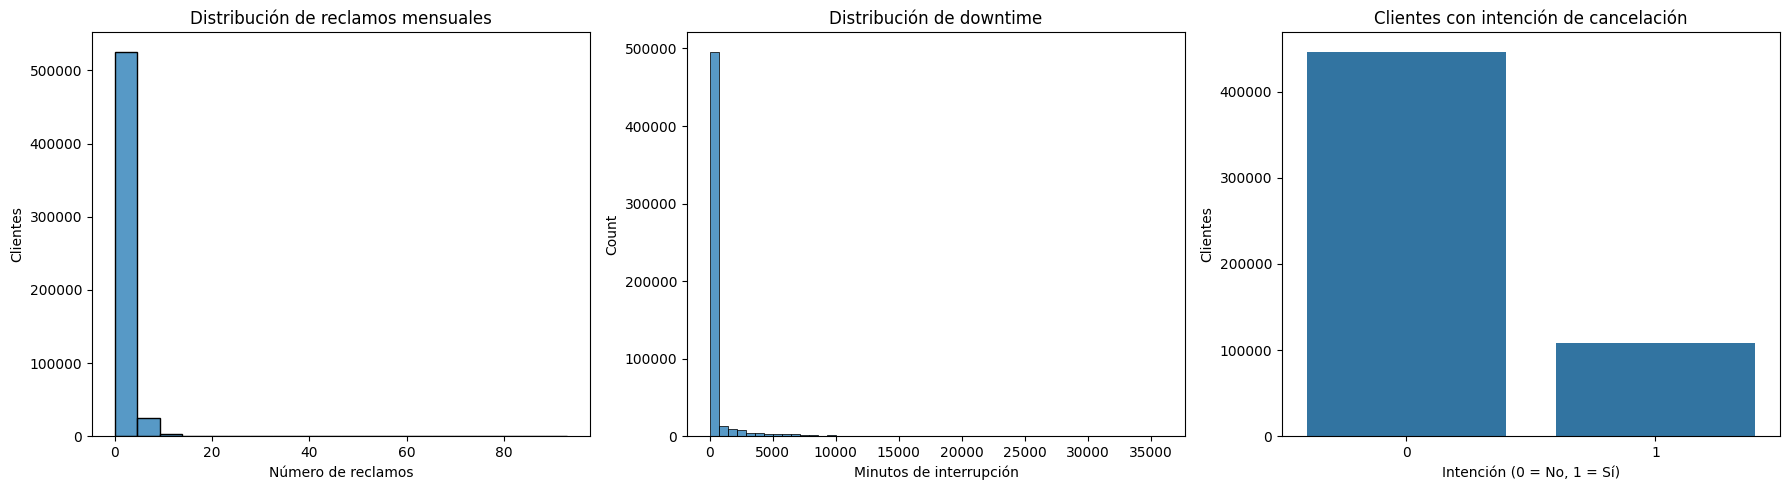

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Reclamos
sns.histplot(cluster["VAL_RECLAMOS_MES"], bins=20, ax=axes[0])
axes[0].set_title("Distribución de reclamos mensuales")
axes[0].set_xlabel("Número de reclamos")
axes[0].set_ylabel("Clientes")

# Downtime
sns.histplot(cluster["VAL_DOWNTIME"], bins=50, ax=axes[1])
axes[1].set_title("Distribución de downtime")
axes[1].set_xlabel("Minutos de interrupción")

# Intención de cancelación
sns.countplot(x=cluster["BAN_INTENCION_CANCELACION"], ax=axes[2])
axes[2].set_title("Clientes con intención de cancelación")
axes[2].set_xlabel("Intención (0 = No, 1 = Sí)")
axes[2].set_ylabel("Clientes")

plt.tight_layout()

plt.show()

In [107]:
print(cluster["VAL_RECLAMOS_MES"].mean())
print((cluster["VAL_RECLAMOS_MES"] > 0).mean()*100)
## El 37% de clientes tienen al menos 1 reclamo por mes

0.9782167730127219
37.852049878761896


In [110]:
(cluster["VAL_DOWNTIME"] > 0).mean()*100
## 12.1% de clientes experimentaron interrupciones del servicio

np.float64(12.101292365782392)

In [114]:
cluster["BAN_INTENCION_CANCELACION"].mean()*100
## Al menos un 20% de los clientes tuvieron intentos de cancelación

np.float64(19.543474579629834)

In [210]:
cluster["BAN_MORA_30"].mean()*100
## Solo el 1% presenta una mora de más de 30 días.

np.float64(0.978551844152288)

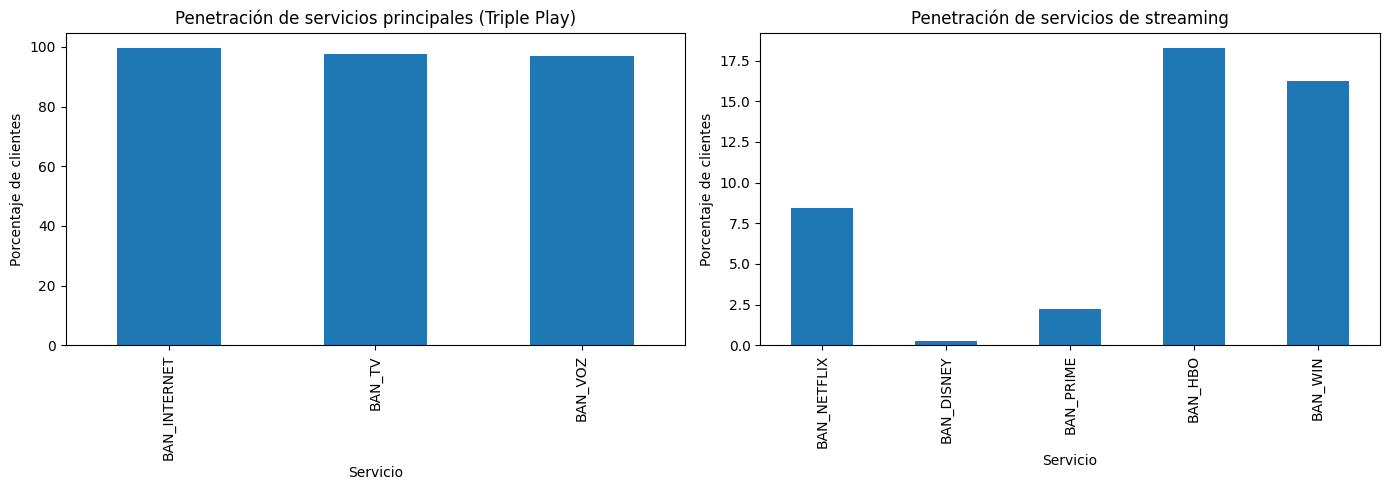

In [211]:
services = ["BAN_INTERNET","BAN_TV","BAN_VOZ"]
streaming = ["BAN_NETFLIX","BAN_DISNEY","BAN_PRIME","BAN_HBO","BAN_WIN"]

services_usage = cluster[services].mean()*100
streaming_usage = cluster[streaming].mean()*100

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Triple Play
services_usage.plot(kind="bar", ax=axes[0])
axes[0].set_title("Penetración de servicios principales (Triple Play)")
axes[0].set_ylabel("Porcentaje de clientes")
axes[0].set_xlabel("Servicio")

# Streaming
streaming_usage.plot(kind="bar", ax=axes[1])
axes[1].set_title("Penetración de servicios de streaming")
axes[1].set_ylabel("Porcentaje de clientes")
axes[1].set_xlabel("Servicio")

plt.tight_layout()

plt.show()

In [116]:
print(cluster["BAN_INTERNET"].mean()*100)
print(cluster["BAN_TV"].mean()*100)
print(cluster["BAN_VOZ"].mean()*100)
## La mayoria de los clientes tienen los 3 servicios contratados (Triple Play), es decir son clientes con paquetes completos.

99.72942104751165
97.77375852539876
97.00903971493733


In [120]:
streaming = ["BAN_NETFLIX","BAN_DISNEY","BAN_PRIME","BAN_HBO","BAN_WIN"]
cluster[streaming].mean()*100

## Sin embargo, no es un cluster de mucho uso de streaming. La adquisición de plataformas es relativamente baja.

,0
BAN_NETFLIX,8.428660
BAN_DISNEY,0.239053
BAN_PRIME,2.205705
BAN_HBO,18.286417
BAN_WIN,16.244645


In [111]:
print("Antigüedad promedio de clientes:", cluster["ANTIGUEDAD_MESES"].mean(), "meses")
print("Clientes con intención de cancelación", cluster["BAN_INTENCION_CANCELACION"].mean()*100,"%")
print("Clientes con mora mayor a 30 días:", cluster["BAN_MORA_30"].mean()*100,"%")
print("Promedio de reclamos por cliente al mes:", cluster["VAL_RECLAMOS_MES"].mean())
print("Clientes que experimentaron al menos una interrupción del servicio:", (cluster["VAL_DOWNTIME"] > 0).mean()*100,"%")
print("Porcentaje de uso de servicios:", cluster[["BAN_INTERNET","BAN_TV","BAN_VOZ"]].mean()*100,"%")


Antigüedad promedio de clientes: 79.9471470313778 meses
Clientes con intención de cancelación 19.543474579629834 %
Clientes con mora mayor a 30 días: 0.978551844152288 %
Promedio de reclamos por cliente al mes: 0.9782167730127219
Clientes que experimentaron al menos una interrupción del servicio: 12.101292365782392 %
Porcentaje de uso de servicios: BAN_INTERNET    99.729421
BAN_TV          97.773759
BAN_VOZ         97.009040
dtype: float64 %


**Perfilamiento de los clientes:**
A partir del EDA realizado, se pueden resaltar caracteristicas como:

* La antiguedad promedio de los clientes es de 80 meses, es decir aprox 6 años y medio; es decir son clientes con una relación larga con la compañia.
* La mayoria de clientes cuentan con paquetes completos de servicios y gran cantidad de servicios adicionales contratados, por lo que serian clientes de gran impacto en caso de cancelación.
* Los clientes pertenecen a una clase media, siendo los principales estratos:2 y 3.
* La renta promedio mensual está sobre los 96.000 y no se observan cambios brusco en la facturación en los ultimos meses. Frente al comportamiento de pago, vemos que muy pocos, solo el 1% tiene una mora superior a 30 dias
* Aproximadamente el 38% de los clientes presenta al menos un reclamo mensual y cerca del 12.1% de los clientes experimentó interrupciones del servicio, lo que infiere que el churn se puede deber a problemas en la experiencia del cliente y calidad del servicio.


## **Análisis Transcripción de llamadas**

In [145]:
##Tamaño del DF
llamadas.shape

(9248, 3)

In [146]:
## Vista del DF
llamadas.head()

,ID,transcription,cluster
0,1,CLIENT: [NOMBRE] obtener hecho esto primero de...,3
1,2,"AGENT: [NOMBRE] entonces, por favor. [NOMBRE] ...",3
2,3,AGENT: ¿[NOMBRE] días me han venido daría canc...,3
3,4,"AGENT: ¿[NOMBRE], me escucha?\nCLIENT: [NOMBRE...",3
4,5,AGENT: ¿[NOMBRE] gracias por su amable espera ...,3


In [147]:
## Revisión que las llamadas pertenezcan al cluster 3
llamadas["cluster"].value_counts()

,count
cluster,
3,5957
6,1408
7,962
1,548
2,373


In [159]:
##Filtramos llamadas solo de nuestro cluster crítico:
llamadas_cluster3 = llamadas[llamadas["cluster"] == 3].copy()

In [160]:
llamadas_cluster3.shape

(5957, 3)

In [162]:
## Limpieza básica del texto

def clean_text(text):
    text = str(text).lower()                ## Convertimos todo a minuscula
    text = re.sub(r'\d+', ' ', text)        ## Quitamos numeros
    text = re.sub(r'[^\w\s]', '', text)     ## Quitamos puntuaciones
    text = re.sub(r'\s+', ' ', text)        ## Quitamos espacios extra

    return text.strip()

llamadas_cluster3["clean_text"] = llamadas_cluster3["transcription"].apply(clean_text)

In [163]:
llamadas_cluster3.head()

,ID,transcription,cluster,clean_text
0,1,CLIENT: [NOMBRE] obtener hecho esto primero de...,3,client nombre obtener hecho esto primero debem...
1,2,"AGENT: [NOMBRE] entonces, por favor. [NOMBRE] ...",3,agent nombre entonces por favor nombre momento...
2,3,AGENT: ¿[NOMBRE] días me han venido daría canc...,3,agent nombre días me han venido daría cancelac...
3,4,"AGENT: ¿[NOMBRE], me escucha?\nCLIENT: [NOMBRE...",3,agent nombre me escucha client nombre antiguos...
4,5,AGENT: ¿[NOMBRE] gracias por su amable espera ...,3,agent nombre gracias por su amable espera en l...


In [166]:
## Ya que dentro de las transcripciones hay palabras comunes que no nos aportan significado, creamos el array para poder omitirlas en el analisis

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [167]:
## Realizamos la vectorización del texto
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stop_words) ##Omitimos los stop_words en el conteo

X = vectorizer.fit_transform(llamadas_cluster3["clean_text"])

words = vectorizer.get_feature_names_out()
freq = X.sum(axis=0).A1

In [194]:
## Creamos la tabla de frecuencias de palabras

freq_df = pd.DataFrame({
    "word": words,
    "frequency": freq
}).sort_values(by="frequency", ascending=False)

freq_df.head(20)

,word,frequency
37925,servicio,35720
18668,fecha,25500
25293,línea,16214
18375,factura,14769
7133,cancelación,14643
23038,internet,12552
12146,cuenta,11755
39700,tarifa,11693
38347,sistema,11220
26724,mes,11119


In [196]:
## Siguen existiendo palabras propias del contexto del call center, por lo que ampliamos los stop_words:
stop_words_extra = [
"cliente","client","agent","agente","nombre","momento","favor","gracias","si","sí","pues","entonces","usted","ustedes",
"aqui","aquí","numero","número","telefono","teléfono", "dia","día","dias","días", "sra", "hacer", "caso", "bien", "va",
"voy", "sé", "puedo", "ver", "dos", "claro", "ahí", "así", "bueno", "tal", "documento", "digo", "hoy", "dice", "puede", "listo",
"validacion", "verdad", "vamos", "mismo", "direccion", "ahorita", "direccion", "acá"]
stop_words = stop_words + stop_words_extra

In [197]:
## Realizamos nuevamente el proceso de vectorización y creación de tabla de frecuencias:

vectorizer = CountVectorizer(stop_words=stop_words)
X = vectorizer.fit_transform(llamadas_cluster3["clean_text"])
words = vectorizer.get_feature_names_out()
freq = X.sum(axis=0).A1

freq_df = pd.DataFrame({
    "word": words,
    "frequency": freq
}).sort_values(by="frequency", ascending=False)

freq_df.head(20)

,word,frequency
37924,servicio,35720
18667,fecha,25500
25292,línea,16214
18374,factura,14769
7132,cancelación,14643
23037,internet,12552
12145,cuenta,11755
39699,tarifa,11693
38346,sistema,11220
26723,mes,11119


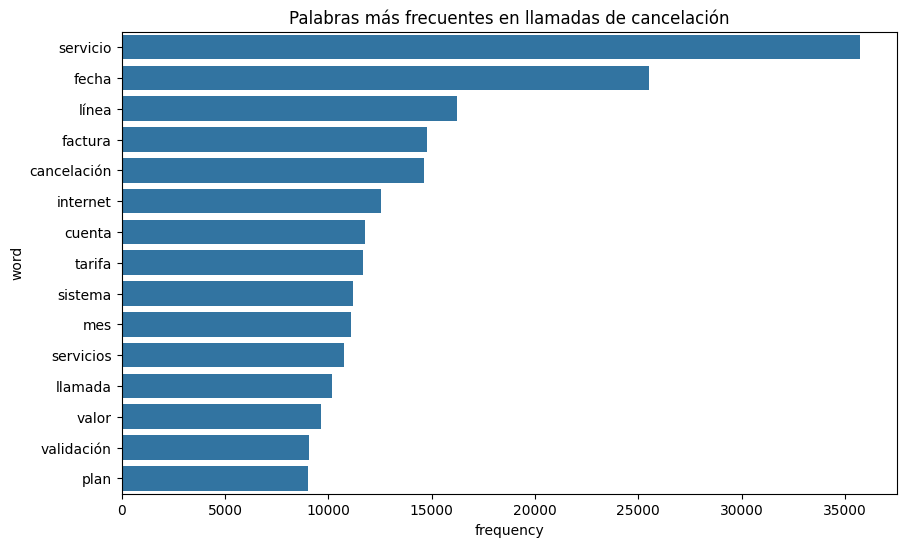

In [203]:
top = freq_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="frequency",
    y="word"
)

plt.title("Palabras más frecuentes en llamadas de cancelación")

plt.show()

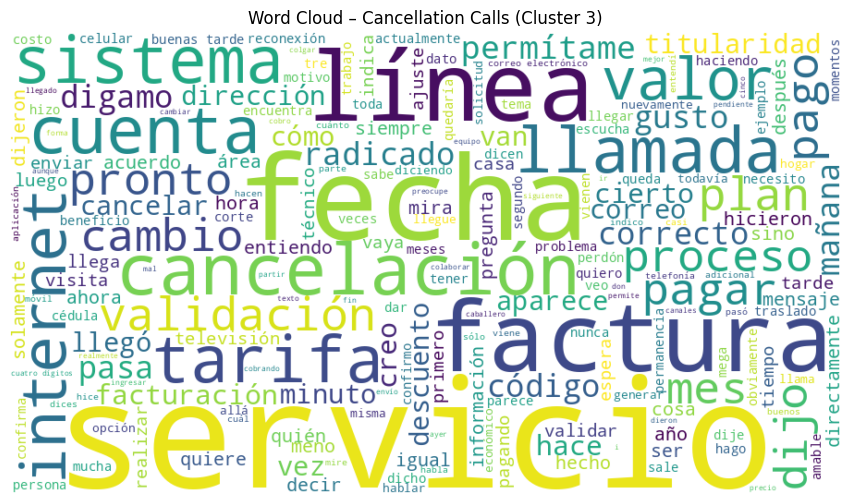

In [198]:
## Vemos visualmente la frecuencia de palabras encontradas.

from wordcloud import WordCloud

text = " ".join(llamadas_cluster3["clean_text"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Cancellation Calls (Cluster 3)")
plt.show()

Realizamos una agrupación, que nos pueda ayudar a identificar los principales temas por los que se puede presentar el churn

* Las palabras factura, valor ,tarifa, pagar, cuenta, mes, podría clasificarse en la razón 1: problemas con facturación o cobros
* Las palabras cancelar, cancelar, proceso, podría clasificarse en la razón 2:
clientes solicitando directamente cancelar el servicio
* Las palabras internet, servicio, servicios, linea podría clasificarse en la razón 3: problemas relacionados con el servicio y calidad del mismo

## **Relación EDA - NLP**

De lo encontrado en el analisis exploratorio y el NLP a las llamadas, podemos concluir:

| Motivo | Evidencia |
| :--- | :---: |
| Problemas de facturación | palabras: factura, tarifa, pagar, valor |
| Experiencia del cliente | 37.8% con reclamos |
| Problemas técnicos | downtime + palabras internet / servicio |

## **Diseño de Estrategias**

Para atacar el motivo 1: **Problemas de Facturación**, se podría:

***Estrategia reactiva***
* Implementar un protocolo de resolución prioritaria para reclamos relacionados con facturación, que incluya una revisión, correción y compensación de cargos en la factura.

***Estrategia Proactiva***

* Implementar un sistema de alertas preventivas de facturación. Donde se le notifique al cliente antes de cambios en la tarifa tarifa y se realicen llamadas explicando cambios o realizando comparativo con facturas anteriores.

Para atacar el motivo 2: **Problemas de Experiencia del cliente**, se podría:

***Estrategia reactiva***
* Implementar un sistema de gestión prioritario de reclamos para clientes del cluster crítico, incluyendo atención prioritaria en call center y resolución acelerada de incidencias.

***Estrategia Proactiva***
* Implementar un sistema de alertas preventivas de reclamación, monitoreando clientes con alta frecuencia de reclamos. También un programa de llamadas proactivas con algún tipo de compensación o seguimiento prioritario.

Para atacar el motivo 3: **Problemas técnicos**, se podría:

***Estrategia reactiva***
* Crear un protocolo de atención prioritaria para fallas técnicas en clientes del cluster crítico: Asignación prioritario de visitas técnicas, escalamiento automatico de casos de alto downtime.

***Estrategia Proactiva***
* Implementar un sistema de monitorio preventivo de red, identificando nodos con alta incidencia y realizando mantenimientos preventivos para poder hacer una intervención antes del reclamo.

Adicional, para atacar los 3 motivos, también se puede implementar Bundles de contenido streaming para clientes con intención de cancelación, ya que como observamos en el EDA, hay espacio para estrategias de fidelización usando plataformas streaming.





## **Métricas de Impacto**


En el EDA se identificaron:
- 19.5% de los clientes presentan intención de cancelación (1 de cada 5 clientes). Se estimaría una reducción de un 5%
- 37.8% de los clientes presentan al menos un reclamo mensual (4 de cada 10). Según búsquedas, un programa normal de recovery podría lograr una reducción del 10%
- 12.1% de los clientes experimentan interrupciones del servicio (1 de cada 8). Según busquedas, los mantenimientos preventivos podrían llegar a realizar una disminución de al menos 5%

Con base en estos indicadores, se proponen los siguientes objetivos de mejora para evaluar el impacto de las iniciativas estratégicas:

| Métrica | Valor actual | Objetivo |
|------|------|------|
Intención de cancelación | 19.5% | 14–16% |
Clientes con reclamos | 37.8% | <34% |
Clientes con downtime | 12.1% | <10% |
